# E2 — PhoBERT fine-tuning — KHÔNG class weight

**Vietnamese Punctuation Restoration · Notebook 2 / 4**

> **Cách chạy:** mở notebook này và chạy **tuần tự từ trên xuống dưới, không bỏ
> cell nào**. Điều kiện tiên quyết: đã chạy
> `python scripts/run_data_pipeline.py` thành công.
>
> **Notebook chỉ đọc `train.jsonl` và `validation.jsonl`.**
> `test.jsonl` không được nạp, không được đánh giá, không được nhìn.
>
> Toàn bộ code huấn luyện nằm trong `src/`; notebook chỉ đóng vai trò điều phối
> và giải thích.


# 1. Experiment Overview

**E2 là thí nghiệm PhoBERT tham chiếu.**

Bài toán vẫn là *word-level sequence labeling* với 4 nhãn `O / COMMA / PERIOD /
QUESTION`, nhãn của một từ mô tả dấu câu đứng **sau** từ đó.

**Vì sao dùng PhoBERT?** BiLSTM ở E1 chỉ biết những gì có trong 4.9 triệu token
của tập train. PhoBERT (`vinai/phobert-base-v2`) đã được tiền huấn luyện trên
hàng chục GB văn bản tiếng Việt, nên nó đã "biết" ngữ pháp, cấu trúc câu hỏi
(`… chưa?`, `… không?`, `… à?`) và ranh giới câu trước khi ta huấn luyện. Đây
thường là yếu tố quyết định trong khôi phục dấu câu.

**E2 khác gì E3 và E4?** *Chỉ khác đúng một dòng trong file config*:

```yaml
loss:
  weight_mode: none


```

Mọi thứ khác — seed 42, dữ liệu, batch size, learning rate, scheduler, số epoch —
đều giống hệt nhau. Nhờ vậy, nếu E3 hoặc E4 cho kết quả khác E2 thì ta biết
chắc nguyên nhân là **cách xử lý mất cân bằng lớp**, không phải yếu tố nào khác.
Đây chính là thiết kế thí nghiệm có kiểm soát (controlled experiment).

**Vấn đề mất cân bằng lớp.** Trong tập train:

| nhãn | tỉ lệ |
|----------|--------|
| `O` | 91.10% |
| `COMMA` | 4.62% |
| `PERIOD` | 3.73% |
| `QUESTION` | 0.56% |

Một mô hình đoán `O` cho mọi từ đã đạt 91% accuracy mà hoàn toàn vô dụng. E2
**không** làm gì để chống lại điều này — nó dùng CrossEntropyLoss mặc định.
Đó chính là điều ta muốn đo: PhoBERT tự nó xử lý mất cân bằng tốt tới đâu.

> ⚠️ **Notebook này KHÔNG bao giờ đọc `test.jsonl`.** Chỉ dùng `train.jsonl` để
> huấn luyện và `validation.jsonl` để đánh giá + chọn checkpoint.

In [1]:

import os, sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "src").exists(), f"Cannot locate the repo root from {Path.cwd()}"
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd


from src.data.constants import (
    LABELS, LABEL2ID, PUNCTUATION_LABELS, MONITOR_METRIC,
    PROCESSED_FILES, OUTPUT_DATA_DIR, CHECKPOINT_DIR, EXPERIMENT_DIR, SEED,
)
from src.data.dataset import load_examples
from src.evaluation.evaluator import predict_word_labels, sample_predictions
from src.evaluation.metrics import format_metrics_table
from src.models.factory import load_model_from_checkpoint
from src.training.seed import set_seed
from src.utils.environment import collect_environment, format_environment
from src.utils.io import read_json, read_yaml
from src.utils.logging_utils import configure_stdout_utf8

configure_stdout_utf8()

EXPERIMENT_ID = "E2"
CONFIG_PATH   = PROJECT_ROOT / "configs" / "e2_phobert_none.yaml"

print(f"Project root : {PROJECT_ROOT}")
print(f"Experiment   : {EXPERIMENT_ID}")
print(f"Config       : {CONFIG_PATH.relative_to(PROJECT_ROOT)}\n")
print(format_environment())

Project root : <USER_HOME>/Documents\GitHub\NLPgrSix7
Experiment   : E2
Config       : configs\e2_phobert_none.yaml

Python version      : 3.12.4
Platform            : Windows-11-10.0.26100-SP0
PyTorch version     : 2.13.0+cu126
CUDA available      : True
CUDA runtime        : 12.6
GPU name            : NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory (GB)     : 8.0
Transformers version: 5.14.1
NumPy version       : 2.5.1


# 2. Dataset

**Nguồn:** [JointCapPunc](https://github.com/ductho9799/JointCapPunc) (Apache-2.0),
ghim ở commit `ee258cae0e95e64245428d59ebbb030280fcebec`.

**Split chính thức được giữ nguyên tuyệt đối:**

| file gốc | split của đồ án | dùng trong notebook này |
|---|---|---|
| `train.txt` | `train` | ✅ huấn luyện |
| `dev.txt` | `validation` | ✅ đánh giá + chọn checkpoint |
| `test.txt` | `test` | ❌ **không đụng đến** — để dành cho Phase 2 |

Không gộp rồi chia lại ngẫu nhiên, không chuyển ví dụ giữa các split.

**Dữ liệu đã qua pipeline** (`scripts/run_data_pipeline.py`): parse nghiêm ngặt →
chuẩn hoá Unicode NFC (giữ nguyên dấu thanh) → ánh xạ `QMARK → QUESTION` →
cắt đoạn ≤150 từ ưu tiên tại `PERIOD`/`QUESTION` → khử trùng lặp trong từng
split → kiểm tra → thống kê.

**Hash dữ liệu.** Mỗi split có `content_sha256` riêng, được chép vào
`outputs/experiments/<E>/data_hashes.json` và vào metadata của checkpoint. Nhờ
đó luôn chứng minh được checkpoint này được huấn luyện trên đúng bộ dữ liệu nào.

In [2]:

config = read_yaml(CONFIG_PATH)


data_cfg = config["data"]
assert "test" not in json.dumps(data_cfg), "test split must not appear in the training config"
print("Files this notebook is allowed to read:")
print("  train      :", data_cfg["train_file"])
print("  validation :", data_cfg["validation_file"])
print("  test       : NOT LOADED  <-- reserved for Phase 2\n")


data_hashes = read_json(OUTPUT_DATA_DIR / "data_hashes.json")
for split in ("train", "validation"):
    h = data_hashes[split]
    print(f"  {split:<11} {h['num_examples']:>7,} examples  "
          f"{h['num_tokens']:>11,} tokens  content_sha256={h['content_sha256'][:16]}…")

set_seed(int(config["training"]["seed"]))

t0 = time.time()
train_examples      = load_examples(PROCESSED_FILES["train"])
validation_examples = load_examples(PROCESSED_FILES["validation"])
print(f"\nLoaded {len(train_examples):,} train / {len(validation_examples):,} validation "
      f"examples in {time.time() - t0:.1f}s")

Files this notebook is allowed to read:
  train      : data/processed/train.jsonl
  validation : data/processed/validation.jsonl
  test       : NOT LOADED  <-- reserved for Phase 2

  train        38,066 examples    4,940,478 tokens  content_sha256=138983bc2761546f…
  validation   15,227 examples    1,977,406 tokens  content_sha256=874133954b31fbfd…
2026-08-09 21:49:19 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 21:49:22 | INFO    | src.data.dataset | Loaded 38066 examples from train.jsonl
2026-08-09 21:49:23 | INFO    | src.data.dataset | Loaded 15227 examples from validation.jsonl

Loaded 38,066 train / 15,227 validation examples in 3.4s


In [3]:

stats = read_json(OUTPUT_DATA_DIR / "data_statistics.json")

rows = []
for split in ("train", "validation"):
    s = stats["splits"][split]
    row = {"split": split, "examples": s["num_examples"], "tokens": s["num_tokens"],
           "mean_len": round(s["mean_length"], 1), "max_len": s["max_length"]}
    for lab in LABELS:
        row[f"%{lab}"] = round(100 * s["label_ratios"][lab], 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("split"))

ex = train_examples[0]
print("\nVí dụ một dòng dữ liệu (10 từ đầu):")
for tok, lab in list(zip(ex.tokens, ex.labels))[:10]:
    print(f"   {tok:<14} -> {lab}")
print(f"   … tổng cộng {len(ex.tokens)} từ, id={ex.id}, source_id={ex.source_id}")

,examples,tokens,mean_len,max_len,%O,%COMMA,%PERIOD,%QUESTION
split,,,,,,,,
train,38066,4940478,129.8,150,91.101,4.616,3.728,0.556
validation,15227,1977406,129.9,150,91.058,4.643,3.743,0.556



Ví dụ một dòng dữ liệu (10 từ đầu):
   hơn            -> O
   2              -> O
   tháng          -> O
   qua            -> O
   amidan         -> O
   khẩu           -> O
   cái            -> O
   của            -> O
   em             -> O
   có             -> O
   … tổng cộng 93 từ, id=train_000001, source_id=train_seg_000001


# 3. Model

**`vinai/phobert-base-v2` + đầu ra token classification**
(`src/models/phobert.py`):

```
input_ids  (batch, ≤192 subword)
    │
    ▼
RoBERTa encoder  (12 layer, hidden 768, 12 attention head)   ← đã tiền huấn luyện
    │                                          (batch, seq, 768)
    ▼
Dropout
    │
    ▼
Linear(768 → 4)                                ← khởi tạo ngẫu nhiên, học từ đầu
    │
    ▼
logits (batch, seq, 4)
```

Tổng cộng ~135 triệu tham số, **tất cả đều được fine-tune** (không đóng băng
lớp nào).

**Revision được ghim (pinned).** Model không chỉ được gọi theo tên mà theo đúng
commit trên Hugging Face:

```
vinai/phobert-base-v2 @ fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
```

Điều này bắt buộc vì E2/E3/E4 phải xuất phát từ **cùng một bộ trọng số ban
đầu**. Nếu Hugging Face cập nhật model, ba thí nghiệm sẽ không còn so sánh được
với nhau và toàn bộ kết luận về class weight sẽ mất giá trị.

**Vì sao PhoBERT chứ không phải mBERT/XLM-R?** PhoBERT được tiền huấn luyện
riêng cho tiếng Việt với bộ từ vựng BPE xây trên âm tiết tiếng Việt, nên một âm
tiết thường chỉ tách thành 1 subword. Các model đa ngữ tách tiếng Việt vụn hơn
nhiều, làm chuỗi dài ra và việc gán nhãn theo từ khó hơn.

**Model trả về logits thô.** Wrapper của chúng ta *không* truyền `labels` vào
Hugging Face, vì mỗi thí nghiệm cần một hàm loss khác nhau (có/không class
weight). Loss được tính trong trainer.

# 4. Tokenization / Vocabulary

Đây là phần tinh tế nhất của toàn bộ pipeline PhoBERT.

**Vấn đề.** PhoBERT dùng BPE, một *từ vựng* (lexical word) có thể bị tách thành
nhiều *subword*. Nhưng nhãn của ta gắn với **từ**, và mô tả dấu câu đứng **sau
cả từ đó**. Vậy nhãn phải đặt ở đâu?

**Quy tắc: nhãn đặt tại SUBWORD CUỐI CÙNG của từ.**
Mọi vị trí còn lại được gán `IGNORE_INDEX = -100`:

```
từ:        [ hoàn ]  [ thành ]  [   chưa   ]
subword:    ho@@ àn   thành      ch@@  ưa
nhãn:       -100  O   PERIOD     -100  QUESTION
                  ▲   ▲                 ▲
                  └───┴─── mỗi từ được giám sát ĐÚNG MỘT LẦN, tại subword cuối
```

`-100` cũng được gán cho `<s>`, `</s>` và các vị trí padding.

**Vì sao là subword cuối chứ không phải subword đầu?** Vì dấu câu đứng *sau* từ.
Subword cuối là vị trí gần dấu câu nhất và là vị trí đã "đọc" xong toàn bộ từ.
Nếu đặt nhãn ở subword đầu, mô hình phải dự đoán dấu câu trước khi đọc hết từ.

**Bất biến được kiểm tra bằng test tự động** (`tests/test_alignment.py`):
mỗi từ được giám sát đúng một lần, không từ nào bị mất, thứ tự không đổi.

**Cửa sổ 192 subword.** Một ví dụ có tối đa 150 từ; tiếng Việt qua PhoBERT
thường ~1.05 subword/từ nên hầu hết vừa trong 192. Khi vượt quá,
`align_words_to_subwords()` **cắt thành nhiều cửa sổ tại ranh giới từ** — không
bao giờ truncate âm thầm. Một từ không bao giờ bị chia đôi giữa hai cửa sổ, nên
gộp dự đoán của các cửa sổ lại là khôi phục đúng chuỗi nhãn đầy đủ.

**Tối ưu tốc độ.** `PhoBERTEncoder` nhớ (memoize) kết quả tách subword theo từ.
Corpus chỉ có ~31k từ khác nhau trên hàng triệu token, nên sau vài nghìn ví dụ
việc tokenize gần như chỉ còn là tra từ điển.

In [4]:

from src.data.constants import IGNORE_INDEX, PHOBERT_MAX_LENGTH
from src.data.dataset import PhoBERTEncoder
from src.models.phobert import load_phobert_tokenizer

tokenizer = load_phobert_tokenizer(config["model"]["name"], config["model"]["revision"])
print(f"Tokenizer     : {type(tokenizer).__name__}")
print(f"Model         : {config['model']['name']}")
print(f"Revision      : {config['model']['revision']}")
print(f"Vocab size    : {tokenizer.vocab_size:,}")
print(f"Window length : {config['model']['max_length']} subwords\n")

encoder = PhoBERTEncoder(tokenizer, max_length=int(config["model"]["max_length"]))


from src.data.schema import Example
demo = Example(
    id="demo", source_split="train", source_id="demo_seg", chunk_index=0,
    tokens="bạn đã hoàn thành bài tập chưa ngày mai chúng ta nộp bài".split(),
    labels=["O"] * 6 + ["QUESTION"] + ["O"] * 5 + ["PERIOD"],
)
(window,) = encoder.encode_example(demo)
id2label = {v: k for k, v in LABEL2ID.items()}

print(f"{'pos':>4}  {'subword':<14}{'label':<10}{'thuộc từ':<10}")
print("-" * 44)
for pos, (sid, lab, widx) in enumerate(zip(window.input_ids, window.labels, window.word_index)):
    piece = tokenizer.convert_ids_to_tokens([sid])[0]
    label_txt = "IGNORE(-100)" if lab == IGNORE_INDEX else f"{id2label[lab]}"
    word_txt  = "-" if widx < 0 else f"{widx} ({demo.tokens[widx]})"
    print(f"{pos:>4}  {piece:<14}{label_txt:<14}{word_txt}")

supervised = [w for w in window.word_index if w >= 0]
print(f"\nSố từ = {len(demo.tokens)} | số vị trí được giám sát = {len(supervised)} "
      f"| khớp: {supervised == list(range(len(demo.tokens)))}")

2026-08-09 21:49:25 | INFO    | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-08-09 21:49:26 | INFO    | httpx | HTTP Request: HEAD https://huggingface.co/vinai/phobert-base-v2/resolve/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-08-09 21:49:26 | INFO    | httpx | HTTP Request: HEAD https://huggingface.co/vinai/phobert-base-v2/resolve/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-08-09 21:49:26 | INFO    | httpx | HTTP Request: GET https://huggingface.co/api/models/vinai/phobert-base-v2/tree/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-08-09 21:49:26 | INFO    | httpx | HTTP Request: GET https://huggingface.co/api/models/vinai/phobert-base-v2/tree/fb76b7e1f77fa19bc4870e2ad956876f7c81c53f?recursive=true&expand=false "HTTP/1.1 200 OK"
Tokenizer     : PhobertTokenizer
Mo

# 5. Loss Strategy

**`CrossEntropyLoss(weight=None, ignore_index=-100)`** — không dùng class weight.

```python
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
```

**`ignore_index=-100` làm gì?** Mọi vị trí có nhãn `-100` bị loại hoàn toàn khỏi
loss: ô padding, subword không phải cuối từ, và token đặc biệt (`<s>`, `</s>`).
Nhờ vậy loss chỉ được tính trên đúng những vị trí tương ứng 1–1 với một từ thật.

**Vì sao thí nghiệm này *không* chỉnh mất cân bằng?** Vì nó là mốc so sánh. Tập
train có 91.1% nhãn `O`. Câu hỏi cần trả lời bằng số liệu là: *mô hình tự nó xử
lý được bao nhiêu, và việc thêm class weight (E3/E4) có thực sự giúp không?*
Nếu không có E2 thì không có gì để so.

**Điều cần theo dõi:** recall của `QUESTION` (lớp chỉ chiếm 0.56%). Đây là nơi
tình trạng mất cân bằng biểu hiện rõ nhất.

In [5]:

from src.training.losses import get_class_weight_vector, load_class_weights

class_weights_blob = load_class_weights()
weight_mode        = config["loss"]["weight_mode"]
weight_vector      = get_class_weight_vector(weight_mode, class_weights=class_weights_blob)

print(f"weight_mode  : {weight_mode}")
print(f"nguồn trọng số: {class_weights_blob['source_split']} split "
      f"({class_weights_blob['total_train_tokens']:,} tokens)\n")

table = []
for i, lab in enumerate(LABELS):
    table.append({
        "label": lab,
        "train_count": class_weights_blob["counts"][lab],
        "train_share_%": round(100 * class_weights_blob["frequencies"][lab], 3),
        "inverse": round(class_weights_blob["inverse"][lab], 4),
        "sqrt_inverse": round(class_weights_blob["sqrt_inverse"][lab], 4),
        "USED HERE": "1.0 (none)" if weight_vector is None else round(weight_vector[i], 4),
    })
display(pd.DataFrame(table).set_index("label"))

weight_mode  : none
nguồn trọng số: train split (4,940,478 tokens)



,train_count,train_share_%,inverse,sqrt_inverse,USED HERE
label,,,,,
O,4500812,91.101,0.2744,0.5239,1.0 (none)
COMMA,228032,4.616,5.4164,2.3273,1.0 (none)
PERIOD,184186,3.728,6.7058,2.5896,1.0 (none)
QUESTION,27448,0.556,44.9985,6.7081,1.0 (none)


# 6. Hyperparameters

Tất cả tham số đọc từ `configs/e2_phobert_none.yaml` — notebook không hardcode số
nào. Muốn đổi thí nghiệm thì sửa file config, không sửa notebook.

| tham số | giá trị | ghi chú |
|---|---|---|
| epochs | 5 | fine-tuning cần ít lượt |
| batch size (train) | 4 | vừa GPU 8GB ở độ dài 192 |
| gradient accumulation | 4 | → batch hiệu dụng ≈ **16** |
| batch size (eval) | 8 | |
| optimizer | AdamW | bias và LayerNorm **không** bị weight decay |
| learning rate | 3e-5 | chuẩn cho fine-tuning BERT |
| weight decay | 1e-2 | |
| warmup ratio | 0.10 | 10% số optimizer step đầu |
| scheduler | linear warmup → linear decay về 0 | cập nhật mỗi **optimizer step** |
| gradient clipping | 1.0 | unscale trước khi clip khi dùng fp16 |
| loss | CrossEntropyLoss, `weight_mode = none` | **điểm khác biệt duy nhất giữa E2/E3/E4** |
| max_length | 192 subword | dài hơn thì cắt cửa sổ tại ranh giới từ |
| seed | 42 | random, numpy, torch, CUDA, DataLoader |
| mixed precision | fp16 trên CUDA, tự động lùi về fp32 nếu không có GPU | |
| metric chọn checkpoint | validation Punctuation Macro-F1 | |

**Thời gian huấn luyện dự kiến:** khoảng 1.5–3 giờ trên GPU 8GB (5 epoch × ~38k window).

In [6]:

def flatten(prefix, obj, out):
    for k, v in obj.items():
        key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict):
            flatten(key, v, out)
        else:
            out.append({"parameter": key, "value": v})
    return out

display(pd.DataFrame(flatten("", config, [])).set_index("parameter"))

,value
parameter,
experiment.id,E2
experiment.name,PhoBERT — no class weight
experiment.description,Fine-tune vinai/phobert-base-v2 for 4-way toke...
model.type,phobert
model.name,vinai/phobert-base-v2
model.revision,fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
model.num_labels,4
model.max_length,192
model.dropout,None


# 7. Training

Vòng lặp huấn luyện (`src/training/trainer_phobert.py`) cho mỗi epoch:

1. `model.train()`;
2. với từng micro-batch (4 cửa sổ):
   - forward trong `autocast(float16)` nếu có CUDA,
   - tính loss ở fp32 để tránh tràn số,
   - `loss / 4` rồi `backward()` — chia cho số bước tích luỹ để độ lớn gradient
     đúng bằng batch 16 thật;
3. **cứ 4 micro-batch** thì:
   - unscale gradient (fp16), clip norm về 1.0,
   - `optimizer.step()`, `scheduler.step()`, `zero_grad()`;
4. nếu epoch kết thúc giữa chừng một chu kỳ tích luỹ, phần gradient còn lại
   **vẫn được áp dụng** — không có batch nào bị bỏ phí;
5. hết epoch → validation (mục 8) → ghi checkpoint nếu tốt hơn.

Vì sao batch 4 + tích luỹ 4 chứ không phải batch 16 thẳng? Vì batch 16 ở độ dài
192 subword không vừa VRAM 8GB. Tích luỹ gradient cho *cùng* độ lớn cập nhật
với chi phí bộ nhớ của batch 4.

**Ba thứ được ghi lại sau mỗi epoch:** một dòng trong `training_history.csv`
(loss, learning rate, thời gian, toàn bộ metric validation), quyết định
checkpoint, và log in ra màn hình.

In [7]:


from src.training.trainer_phobert import build_phobert_trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")

trainer, tokenizer = build_phobert_trainer(
    config,
    train_examples,
    validation_examples,
    tokenizer=tokenizer,
    data_hashes=data_hashes,
    device=device,
)

n_params = sum(p_.numel() for p_ in trainer.model.parameters())
accum    = trainer.gradient_accumulation_steps
print(f"\nModel parameters      : {n_params:,} ({n_params / 1e6:.1f}M)")
print(f"Train windows         : {len(trainer.train_loader.dataset):,}")
print(f"Validation windows    : {len(trainer.validation_loader.dataset):,}")
print(f"Micro-batches / epoch : {len(trainer.train_loader):,}")
print(f"Optimizer steps/epoch : {len(trainer.train_loader) // accum:,} "
      f"(accumulation = {accum}, effective batch = {trainer.train_loader.batch_size * accum})")
print(f"Mixed precision (fp16): {trainer.use_amp}")

Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
2026-08-09 21:49:27 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 21:49:29 | INFO    | src.data.dataset | Encoded 20000/38066 examples
2026-08-09 21:49:32 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 38066, 'num_windows': 38111, 'num_words': 4940478, 'num_subwords': 5207406, 'windows_per_example': 1.0012, 'subwords_per_word': 1.054, 'examples_split_into_multiple_windows': 45, 'max_window_length': 192}
2026-08-09 21:49:34 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 15227, 'num_windows': 15243, 'num_words': 1977406, 'num_subwords': 2083427, 'windows_per_example': 1.0011, 'subwords_per_word': 1.0536, 'examples_split_into_multiple_windows': 16, 'max_window_length': 192}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-08-09 21:49:34 | INFO    | src.models.phobert | Loaded vinai/phobert-base-v2 @ fb76b7e1f77f (134.4M parameters, num_labels=4)
2026-08-09 21:49:34 | INFO    | src.training.losses | Loss: CrossEntropyLoss(weight_mode=none, weights=None, ignore_index=-100)
2026-08-09 21:49:34 | INFO    | src.training.optimizer | AdamW(lr=3e-05, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-08) — 134,289,408 decayed / 121,348 not decayed params
2026-08-09 21:49:34 | INFO    | src.training.scheduler | Scheduler: linear warmup+decay (1191 warmup / 11910 total optimizer steps, ratio=0.10)

Model parameters      : 134,410,756 (134.4M)
Train windows         : 38,111
Validation windows    : 15,243
Micro-batches / epoch : 9,528
Optimizer steps/epoch : 2,382 (accumulation = 4, effective batch = 16)
Mixed precision (fp16): True


In [8]:




result = trainer.fit()

print("\n" + "=" * 78)
print(f"TRAINING FINISHED — best epoch {result.best_epoch}, "
      f"validation {MONITOR_METRIC} = {result.best_score:.6f}")
print(f"Total time: {result.total_seconds / 60:.1f} min")
print("=" * 78)

2026-08-09 21:49:35 | INFO    | src.training.trainer_base | === E2: training for 5 epoch(s) on cuda (AMP=True) ===


E2 epoch 1 train:   0%|          | 0/9528 [00:00<?, ?it/s]

2026-08-09 21:50:00 | INFO    | src.training.trainer_phobert | epoch 1 step 500/9528 — loss 0.9506 (lr=3.15e-06)
2026-08-09 21:50:28 | INFO    | src.training.trainer_phobert | epoch 1 step 1000/9528 — loss 0.6469 (lr=6.30e-06)
2026-08-09 21:50:53 | INFO    | src.training.trainer_phobert | epoch 1 step 1500/9528 — loss 0.5019 (lr=9.45e-06)
2026-08-09 21:51:17 | INFO    | src.training.trainer_phobert | epoch 1 step 2000/9528 — loss 0.4197 (lr=1.26e-05)
2026-08-09 21:51:41 | INFO    | src.training.trainer_phobert | epoch 1 step 2500/9528 — loss 0.3659 (lr=1.57e-05)
2026-08-09 21:52:05 | INFO    | src.training.trainer_phobert | epoch 1 step 3000/9528 — loss 0.3279 (lr=1.89e-05)
2026-08-09 21:52:29 | INFO    | src.training.trainer_phobert | epoch 1 step 3500/9528 — loss 0.2994 (lr=2.20e-05)
2026-08-09 21:52:53 | INFO    | src.training.trainer_phobert | epoch 1 step 4000/9528 — loss 0.2773 (lr=2.52e-05)
2026-08-09 21:53:17 | INFO    | src.training.trainer_phobert | epoch 1 step 4500/9528 — l

E2 epoch 1 validation:   0%|          | 0/1906 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

E2 epoch 5 train:   0%|          | 0/9528 [00:00<?, ?it/s]

2026-08-09 22:22:54 | INFO    | src.training.trainer_phobert | epoch 5 step 500/9528 — loss 0.0683 (lr=6.32e-06)
2026-08-09 22:23:18 | INFO    | src.training.trainer_phobert | epoch 5 step 1000/9528 — loss 0.0679 (lr=5.97e-06)
2026-08-09 22:23:42 | INFO    | src.training.trainer_phobert | epoch 5 step 1500/9528 — loss 0.0685 (lr=5.62e-06)
2026-08-09 22:24:06 | INFO    | src.training.trainer_phobert | epoch 5 step 2000/9528 — loss 0.0682 (lr=5.27e-06)
2026-08-09 22:24:31 | INFO    | src.training.trainer_phobert | epoch 5 step 2500/9528 — loss 0.0680 (lr=4.92e-06)
2026-08-09 22:24:55 | INFO    | src.training.trainer_phobert | epoch 5 step 3000/9528 — loss 0.0680 (lr=4.57e-06)
2026-08-09 22:25:19 | INFO    | src.training.trainer_phobert | epoch 5 step 3500/9528 — loss 0.0682 (lr=4.22e-06)
2026-08-09 22:25:43 | INFO    | src.training.trainer_phobert | epoch 5 step 4000/9528 — loss 0.0683 (lr=3.87e-06)
2026-08-09 22:26:07 | INFO    | src.training.trainer_phobert | epoch 5 step 4500/9528 — l

E2 epoch 5 validation:   0%|          | 0/1906 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-08-09 22:30:42 | INFO    | src.training.checkpointing | Epoch 5: new best punctuation_macro_f1=0.778718 (was 0.775125) — checkpoint written to outputs\checkpoints\E2

[E2] epoch 5/5 (8.2 min) — train_loss=0.0679 val_loss=0.0904 val_PUNCT_F1=0.7787  <-- new best
label       precision    recall        f1     support
-----------------------------------------------------
O              0.9863    0.9863    0.9863   1,800,593
COMMA          0.7437    0.7110    0.7270      91,818
PERIOD         0.7967    0.8255    0.8108      74,008
QUESTION       0.7513    0.8516    0.7983      10,987
-----------------------------------------------------
accuracy       0.9667
macro F1       0.8306   (all 4 classes)
PUNCT-F1       0.7787   <-- model selection metric (COMMA/PERIOD/QUESTION)

TRAINING FINISHED — best epoch 5, validation punctuation_macro_f1 = 0.778718
Total time: 41.1 min


# 8. Validation

Validation chạy **sau mỗi epoch**, trên toàn bộ `validation.jsonl` (tập `dev`
chính thức của JointCapPunc). Chỉ những vị trí có nhãn khác `-100` được tính —
tức là đúng một vị trí cho mỗi từ.

**Metric chính để chọn checkpoint: Punctuation Macro-F1**

$$\text{PUNCT-F1} = \frac{F1_{COMMA} + F1_{PERIOD} + F1_{QUESTION}}{3}$$

**Vì sao loại `O` ra khỏi metric chính?** Vì `O` chiếm 91% dữ liệu. Một mô hình
đoán `O` cho mọi từ đạt:

* accuracy = **0.911** (nghe rất cao),
* macro-F1 4 lớp = **0.238** (vẫn khác 0),
* Punctuation Macro-F1 = **0.000** ← chỉ số duy nhất nói đúng sự thật.

**Vì sao macro chứ không micro?** `QUESTION` chỉ chiếm 0.56% số token. Micro-F1
lấy trung bình theo số lượng nên `QUESTION` gần như vô hình; macro cho ba lớp
trọng số bằng nhau, buộc mô hình phải làm tốt cả lớp hiếm nhất.

Các chỉ số khác (accuracy, macro-F1 4 lớp, micro-F1, precision/recall từng lớp)
vẫn được ghi lại đầy đủ để phân tích, nhưng **không** dùng để chọn checkpoint.

In [9]:

best_metrics = trainer.checkpoints.best_metrics
artifacts    = trainer.artifacts

artifacts.write_best_validation(best_metrics, best_epoch=result.best_epoch)
artifacts.write_per_class(best_metrics)
artifacts.write_confusion_matrix(best_metrics)
artifacts.write_history()

print(f"Best epoch                 : {result.best_epoch}")
print(f"Validation PUNCT Macro-F1  : {best_metrics['punctuation_macro_f1']:.6f}")
print(f"Validation accuracy        : {best_metrics['accuracy']:.6f}")
print(f"Validation macro-F1 (4 cls): {best_metrics['macro_f1']:.6f}")
print(f"Supervised tokens scored   : {best_metrics['num_evaluated_tokens']:,}")

Best epoch                 : 5
Validation PUNCT Macro-F1  : 0.778718
Validation accuracy        : 0.966725
Validation macro-F1 (4 cls): 0.830614
Supervised tokens scored   : 1,977,406


# 9. Training Curves

Hai biểu đồ:

* **trái** — train loss và validation loss theo epoch. Nếu train loss tiếp tục
  giảm trong khi validation loss đi lên thì mô hình bắt đầu overfit;
* **phải** — validation Punctuation Macro-F1 (đường quyết định) cùng macro-F1
  4 lớp. Vòng tròn đỏ đánh dấu epoch tốt nhất, chính là epoch được lưu
  checkpoint.

Khoảng cách giữa hai đường F1 cho thấy lớp `O` "kéo" macro-F1 lên bao nhiêu —
đó là lý do ta không dùng macro-F1 4 lớp để chọn model.

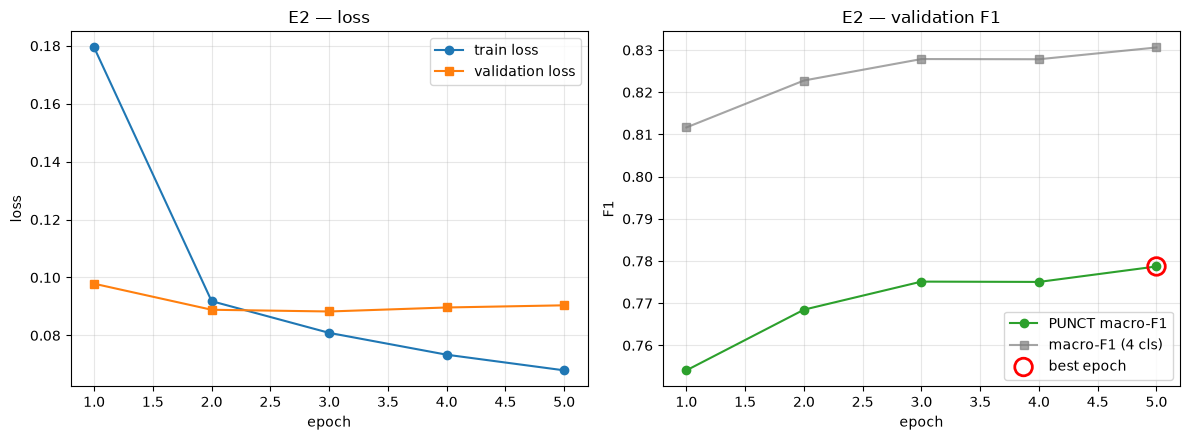

Saved: outputs\experiments\E2\training_curves.png


,epoch,train_loss,val_loss,val_accuracy,val_punctuation_macro_f1,val_f1_COMMA,val_f1_PERIOD,val_f1_QUESTION,learning_rate,epoch_seconds,is_best
0,1,0.17942,0.09785,0.96230,0.75409,0.70007,0.78997,0.77224,0.00000,495.96,1
1,2,0.09182,0.08886,0.96559,0.76847,0.71130,0.80444,0.78968,0.00003,492.69,1
2,3,0.08088,0.08826,0.96635,0.77512,0.72139,0.80724,0.79674,0.00002,492.71,1
3,4,0.07333,0.08964,0.96612,0.77505,0.72342,0.80732,0.79441,0.00001,493.07,0
4,5,0.06793,0.09039,0.96672,0.77872,0.72697,0.81084,0.79834,0.00001,492.52,1


In [10]:

%matplotlib inline
curve_path = artifacts.plot_training_curves(show=True)
print("Saved:", curve_path)

history_df = pd.read_csv(artifacts.path("training_history.csv"))
display(history_df[[
    "epoch", "train_loss", "val_loss", "val_accuracy",
    "val_punctuation_macro_f1", "val_f1_COMMA", "val_f1_PERIOD", "val_f1_QUESTION",
    "learning_rate", "epoch_seconds", "is_best",
]].round(5))

# 10. Best Checkpoint

Chỉ **một** checkpoint được giữ: epoch có validation Punctuation Macro-F1 cao
nhất. Khi có epoch tốt hơn, thư mục được ghi đè — nên không bao giờ nhầm lẫn
giữa "checkpoint cuối cùng" và "checkpoint tốt nhất".

`checkpoint_metadata.json` đi kèm ghi lại toàn bộ ngữ cảnh: experiment id, tên
và revision của model, bảng nhãn, cấu hình huấn luyện, epoch tốt nhất, điểm
validation, hash của dữ liệu, seed, và phiên bản Python / PyTorch /
Transformers / CUDA cùng tên GPU. Nhờ vậy Phase 2 (và người chấm) có thể truy
ngược mọi con số về đúng dữ liệu và môi trường đã tạo ra nó.

In [11]:

ckpt_dir = Path(trainer.checkpoints.checkpoint_dir)
meta     = read_json(ckpt_dir / "checkpoint_metadata.json")

print(f"Checkpoint directory: {ckpt_dir.relative_to(PROJECT_ROOT)}\n")
for f in sorted(ckpt_dir.iterdir()):
    print(f"  {f.name:<32}{f.stat().st_size / 1024:>12,.0f} KB")

print("\nMetadata:")
for key in ("experiment_id", "model_type", "model_name", "model_revision",
            "monitor_metric", "best_epoch", "best_score", "seed",
            "python_version", "torch_version", "transformers_version",
            "cuda_version", "gpu_name"):
    print(f"  {key:<22}: {meta.get(key)}")
print(f"  {'label2id':<22}: {meta.get('label2id')}")
print(f"  {'train content_sha256':<22}: {meta['data_hashes']['train']['content_sha256'][:32]}…")

Checkpoint directory: outputs\checkpoints\E2

  .gitkeep                                   0 KB
  added_tokens.json                          0 KB
  bpe.codes                              1,109 KB
  checkpoint_metadata.json                   6 KB
  config.json                                1 KB
  model.safetensors                    525,065 KB
  tokenizer_config.json                      1 KB
  vocab.txt                                874 KB

Metadata:
  experiment_id         : E2
  model_type            : phobert
  model_name            : vinai/phobert-base-v2
  model_revision        : fb76b7e1f77fa19bc4870e2ad956876f7c81c53f
  monitor_metric        : punctuation_macro_f1
  best_epoch            : 5
  best_score            : 0.7787176875966945
  seed                  : 42
  python_version        : 3.12.4
  torch_version         : 2.13.0+cu126
  transformers_version  : 5.14.1
  cuda_version          : 12.6
  gpu_name              : NVIDIA GeForce RTX 4060 Laptop GPU
  label2id         

# 11. Validation Results

Bảng dưới là kết quả của **epoch tốt nhất** trên toàn bộ validation.

Cách đọc confusion matrix: hàng = nhãn đúng, cột = nhãn mô hình dự đoán. Ô
`gold_PERIOD / pred_O` là số lần mô hình *bỏ sót* một dấu chấm; ô
`gold_O / pred_COMMA` là số lần mô hình *thêm thừa* một dấu phẩy. Hai kiểu lỗi
này có ý nghĩa rất khác nhau khi đánh giá chất lượng thực tế.

In [12]:

print(format_metrics_table(best_metrics))

print("\nConfusion matrix (hàng = gold, cột = predicted)")
cm_df = pd.DataFrame(
    best_metrics["confusion_matrix"],
    index=[f"gold_{l}" for l in LABELS],
    columns=[f"pred_{l}" for l in LABELS],
)
display(cm_df)

print("Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):")
display((cm_df.div(cm_df.sum(axis=1), axis=0) * 100).round(2))

label       precision    recall        f1     support
-----------------------------------------------------
O              0.9863    0.9863    0.9863   1,800,593
COMMA          0.7437    0.7110    0.7270      91,818
PERIOD         0.7967    0.8255    0.8108      74,008
QUESTION       0.7513    0.8516    0.7983      10,987
-----------------------------------------------------
accuracy       0.9667
macro F1       0.8306   (all 4 classes)
PUNCT-F1       0.7787   <-- model selection metric (COMMA/PERIOD/QUESTION)

Confusion matrix (hàng = gold, cột = predicted)


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,1775873,16388,7127,1205
gold_COMMA,17973,65284,7898,663
gold_PERIOD,5734,5951,61094,1229
gold_QUESTION,899,164,567,9357


Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,98.63,0.91,0.40,0.07
gold_COMMA,19.57,71.10,8.60,0.72
gold_PERIOD,7.75,8.04,82.55,1.66
gold_QUESTION,8.18,1.49,5.16,85.16


# 12. Per-Class Results

* **precision** = trong các từ mô hình gán nhãn X, bao nhiêu phần trăm đúng →
  đo mức độ "thêm dấu câu thừa";
* **recall** = trong các từ thực sự mang nhãn X, mô hình bắt được bao nhiêu →
  đo mức độ "bỏ sót dấu câu";
* **F1** = trung bình điều hoà của hai chỉ số trên;
* **support** = số từ thực sự mang nhãn đó trong validation.

`QUESTION` là lớp khó nhất (chỉ ~0.56% dữ liệu) và là nơi khác biệt giữa E2, E3,
E4 sẽ lộ ra rõ nhất. Khi so sánh 4 thí nghiệm ở Phase 2, hãy nhìn cả precision
lẫn recall của lớp này chứ không chỉ nhìn F1 tổng.

In [13]:

per_class_df = pd.read_csv(artifacts.path("per_class_validation_metrics.csv"))
display(per_class_df)

pc = best_metrics["per_class"]
print("Punctuation Macro-F1 = mean of the three punctuation F1 scores:")
print(f"  F1_COMMA    = {pc['COMMA']['f1']:.6f}")
print(f"  F1_PERIOD   = {pc['PERIOD']['f1']:.6f}")
print(f"  F1_QUESTION = {pc['QUESTION']['f1']:.6f}")
print(f"  ---------------------------")
print(f"  PUNCT-F1    = {best_metrics['punctuation_macro_f1']:.6f}")

,label,precision,recall,f1,support,tp,fp,fn
0,O,0.986334,0.986271,0.986302,1800593.0,1775873.0,24606.0,24720.0
1,COMMA,0.743664,0.711015,0.726973,91818.0,65284.0,22503.0,26534.0
2,PERIOD,0.796677,0.825505,0.810835,74008.0,61094.0,15592.0,12914.0
3,QUESTION,0.751325,0.851643,0.798345,10987.0,9357.0,3097.0,1630.0
4,PUNCTUATION_MACRO_F1,NaN,NaN,0.778718,NaN,NaN,NaN,NaN
5,MACRO_F1_ALL_CLASSES,NaN,NaN,0.830614,NaN,NaN,NaN,NaN
6,ACCURACY,NaN,NaN,0.966725,NaN,NaN,NaN,NaN


Punctuation Macro-F1 = mean of the three punctuation F1 scores:
  F1_COMMA    = 0.726973
  F1_PERIOD   = 0.810835
  F1_QUESTION = 0.798345
  ---------------------------
  PUNCT-F1    = 0.778718


# 13. Một số prediction sample trên VALIDATION

Phần này nạp lại **checkpoint tốt nhất** (chứ không dùng model của epoch cuối)
rồi chạy dự đoán trên vài ví dụ đầu của validation, để so sánh trực tiếp câu
gold và câu mô hình sinh ra.

Viết hoa đầu câu chỉ là bước hiển thị cho dễ đọc — mô hình **không** dự đoán
viết hoa, nó chỉ dự đoán dấu câu. (JointCapPunc có cột capitalization nhưng đồ
án này không dùng.)

Đây vẫn là dữ liệu **validation** — không phải test.

In [14]:

best_model, _ = load_model_from_checkpoint(ckpt_dir, device=device)

from torch.utils.data import DataLoader
from src.data.dataset import PhoBERTDataset, collate_phobert

sample_examples = validation_examples[:24]
sample_loader = DataLoader(
    PhoBERTDataset(sample_examples, encoder, log_every=0),
    batch_size=8, shuffle=False,
    collate_fn=lambda b: collate_phobert(b, pad_id=encoder.pad_id),
)

predictions = predict_word_labels(best_model, sample_loader, device=device, use_amp=trainer.use_amp)
rows = sample_predictions(best_model, sample_examples, predictions, n=8)

for r in rows[:5]:
    print(f"--- {r['id']}  ({r['num_words']} từ, token accuracy {r['token_accuracy']:.1%})")
    print(f"  input : {r['input_text'][:150]}")
    print(f"  gold  : {r['gold_text'][:150]}")
    print(f"  pred  : {r['predicted_text'][:150]}\n")

artifacts.write_sample_predictions(rows)
display(pd.DataFrame(rows)[["id", "num_words", "token_accuracy"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-08-09 22:30:44 | INFO    | src.data.dataset | PhoBERT dataset ready: {'num_examples': 24, 'num_windows': 24, 'num_words': 3243, 'num_subwords': 3413, 'windows_per_example': 1.0, 'subwords_per_word': 1.0524, 'examples_split_into_multiple_windows': 0, 'max_window_length': 163}
--- validation_000001  (136 từ, token accuracy 95.6%)
  input : bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em em đi ngoài thế nào em con đi ngoài bình thường ạ con đi khámbs bảo là không 
  gold  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá. Chào em em đi ngoài thế nào em? Con đi ngoài bình thường ạ con đi khámbs bảo là khôn
  pred  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em em đi ngoài thế nào em? Con đi ngoài bình thường ạ con đi khámbs bảo là không

--- validation_000002  (133 từ, token accuracy 99.2%)
  input : vợ chồng em có quan hệ và hoạt động hơi mạnh ngày hôm sau em cảm thấy vùng bụng dưới bị xốn lấy tay sờ vào vùng kín t

,id,num_words,token_accuracy
0,validation_000001,136,0.955882
1,validation_000002,133,0.992481
2,validation_000003,140,0.957143
3,validation_000004,133,0.947368
4,validation_000005,141,0.971631
5,validation_000006,130,1.000000
6,validation_000007,134,0.962687
7,validation_000008,148,0.986486


# 14. Artifact Paths

Cell dưới ghi `experiment_summary.json` với **trạng thái `COMPLETED` và các con
số thật vừa đo được**, rồi liệt kê toàn bộ file mà notebook này đã sinh ra.

Trước khi chạy, file này mang trạng thái `NOT_YET_RUN` — dự án không bao giờ
điền sẵn kết quả giả.

In [15]:

summary_path = artifacts.write_summary(
    model=config['model']['name'],
    weight_mode=config["loss"]["weight_mode"],
    best_epoch=result.best_epoch,
    best_score=result.best_score,
    checkpoint_path=ckpt_dir,
    extra={
        "best_validation_accuracy": best_metrics["accuracy"],
        "best_validation_macro_f1_all_classes": best_metrics["macro_f1"],
        "best_validation_f1_per_class": {
            lab: best_metrics["per_class"][lab]["f1"] for lab in LABELS
        },
        "total_training_seconds": round(result.total_seconds, 1),
        "evaluated_on": "validation.jsonl (official JointCapPunc dev split)",
        "test_split_used": False,
    },
)

print("Artifacts written by this notebook\n")
print(f"{'outputs/experiments/' + EXPERIMENT_ID:<45}")
for f in sorted(artifacts.dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")
print(f"\n{'outputs/checkpoints/' + EXPERIMENT_ID:<45}")
for f in sorted(ckpt_dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")

print("\nexperiment_summary.json:")
print(json.dumps(read_json(summary_path), indent=2, ensure_ascii=False))

2026-08-09 22:30:44 | INFO    | src.training.artifacts | Experiment E2 COMPLETED: {'status': 'COMPLETED', 'experiment_id': 'E2', 'model': 'vinai/phobert-base-v2', 'weight_mode': 'none', 'best_epoch': 5, 'best_validation_punctuation_macro_f1': 0.7787176875966945, 'checkpoint_path': 'outputs/checkpoints/E2', 'monitor_metric': 'punctuation_macro_f1', 'num_epochs_completed': 5, 'completed_at_utc': '2026-08-09T15:30:44+00:00', 'best_validation_accuracy': 0.9667250933799129, 'best_validation_macro_f1_all_classes': 0.8306138687401703, 'best_validation_f1_per_class': {'O': 0.986302412170598, 'COMMA': 0.7269730798140364, 'PERIOD': 0.81083520246327, 'QUESTION': 0.7983447805127768}, 'total_training_seconds': 2467.0, 'evaluated_on': 'validation.jsonl (official JointCapPunc dev split)', 'test_split_used': False}
Artifacts written by this notebook

outputs/experiments/E2                       
   best_validation_metrics.json                     1.6 KB
   config.json                                  

# 15. Experiment Conclusion

Khi đọc kết quả E2, hãy trả lời trong báo cáo:

1. **PhoBERT hơn BiLSTM (E1) bao nhiêu điểm PUNCT-F1?** Đây là giá trị thực tế
   của việc tiền huấn luyện tiếng Việt.
2. **Không dùng class weight, `QUESTION` đạt recall bao nhiêu?** Con số này là
   động cơ của E3 và E4.
3. **Mô hình sai kiểu gì nhiều hơn — bỏ sót dấu câu hay thêm dấu thừa?** Nhìn
   confusion matrix ở mục 11.

### Checklist sau khi chạy xong notebook này

- [ ] `outputs/checkpoints/E2/` có checkpoint (`model.pt` hoặc `model.safetensors`) + `checkpoint_metadata.json`
- [ ] `outputs/experiments/E2/experiment_summary.json` có `"status": "COMPLETED"`
- [ ] `outputs/experiments/E2/best_validation_metrics.json` tồn tại
- [ ] `outputs/experiments/E2/training_history.csv` có đủ số dòng bằng số epoch đã chạy
- [ ] `outputs/experiments/E2/per_class_validation_metrics.csv` tồn tại
- [ ] `outputs/experiments/E2/validation_confusion_matrix.csv` tồn tại
- [ ] `outputs/experiments/E2/training_curves.png` tồn tại

Cell cuối kiểm tra tự động những mục trên.

### Bước tiếp theo

Chạy tiếp `notebooks/03_E3_PhoBERT_InverseWeight.ipynb`.

In [16]:

expected = [
    artifacts.path("config.json"),
    artifacts.path("training_history.csv"),
    artifacts.path("best_validation_metrics.json"),
    artifacts.path("per_class_validation_metrics.csv"),
    artifacts.path("validation_confusion_matrix.csv"),
    artifacts.path("environment.json"),
    artifacts.path("data_hashes.json"),
    artifacts.path("experiment_summary.json"),
    artifacts.path("training_curves.png"),
    ckpt_dir / "checkpoint_metadata.json",
]
ok = True
for path in expected:
    exists = path.exists()
    ok &= exists
    print(f"  [{'OK  ' if exists else 'MISS'}] {path.relative_to(PROJECT_ROOT)}")

summary = read_json(artifacts.path("experiment_summary.json"))
status_ok = summary.get("status") == "COMPLETED"
print(f"\n  [{'OK  ' if status_ok else 'MISS'}] experiment_summary.json status = {summary.get('status')}")

print("\n" + "=" * 78)
if ok and status_ok:
    print(f"{EXPERIMENT_ID} COMPLETED — validation {MONITOR_METRIC} = "
          f"{summary['best_validation_punctuation_macro_f1']:.6f} at epoch "
          f"{summary['best_epoch']}")
    print("Test split was never loaded in this notebook.")
else:
    print(f"{EXPERIMENT_ID} INCOMPLETE — re-run the notebook from the top.")
print("=" * 78)

  [OK  ] outputs\experiments\E2\config.json
  [OK  ] outputs\experiments\E2\training_history.csv
  [OK  ] outputs\experiments\E2\best_validation_metrics.json
  [OK  ] outputs\experiments\E2\per_class_validation_metrics.csv
  [OK  ] outputs\experiments\E2\validation_confusion_matrix.csv
  [OK  ] outputs\experiments\E2\environment.json
  [OK  ] outputs\experiments\E2\data_hashes.json
  [OK  ] outputs\experiments\E2\experiment_summary.json
  [OK  ] outputs\experiments\E2\training_curves.png
  [OK  ] outputs\checkpoints\E2\checkpoint_metadata.json

  [OK  ] experiment_summary.json status = COMPLETED

E2 COMPLETED — validation punctuation_macro_f1 = 0.778718 at epoch 5
Test split was never loaded in this notebook.
